# SAP Role Matching: Phase 3


In [1]:
!pip install gensim openpyxl --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
import pickle
import warnings
import os
import re

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 80)
print('Imports OK')

/Users/manu/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Imports OK


In [2]:
# Configuration

CLUSTERING_METHOD = 'HDBSCAN_GUIDED'  # options:
                                # 'HDBSCAN', 'HDBSCAN_GUIDED', 'GMM',
                                # 'COP_KMEANS', 'FUZZY', 'FCMCL', 'LFM'

# Export file mapping
METHOD_FILES = {
    'HDBSCAN':        'output phase2 JT/hdbscan_clusters_export.xlsx',
    'HDBSCAN_GUIDED': 'output phase2 JT/hdbscan_guided_clusters_export.xlsx',
    'GMM':            'output phase2 JT/gmm_clusters_export.xlsx',
    'COP_KMEANS':     'output phase2 JT/cop_smart_clusters_export.xlsx',
    'FUZZY':          'output phase2 JT/fuzzy_clusters_export.xlsx',
    'FCMCL':          'output phase2 JT/fcmcl_clusters_export.xlsx',
}

# Overlapping methods job titles can belong to multiple clusters
OVERLAPPING_METHODS = {'FUZZY', 'FCMCL', 'LFM'}

# Input paths
PATH_BC = 'input phase3/BusinessCat.xlsx'
PATH_SAP_SR = 'input phase1/SapRolesStandard.xlsx'
PATH_USAGE_MATRIX = 'output phase1 JT/JT_usage_matrix.csv'
OUTPUT_DIR  = f'output phase3/{CLUSTERING_METHOD.lower()}_results'

# Role catalogue filters
MIN_BC_SIZE = 2    
MAX_BC_SIZE = 50  
MIN_ROLE_SIZE = 1  
MAX_ROLE_SIZE = 50 

# Word2Vec
W2V_VECTOR_SIZE = 64   
                       
W2V_WINDOW      = 5    
                       
W2V_MIN_COUNT   = 2    
                        
W2V_EPOCHS      = 100  

# Semantic matching
TOP_CANDIDATES = 100   
                       
                      

# Greedy set cover 
COVERAGE_TARGET = 0.80  
                        
EXCESS_PENALTY  = 0.30  
                        

# Cluster profiles
PREVALENCE_REQUIRED = 0.60  
PREVALENCE_OPTIONAL = 0.25  


SOFT_ALPHA          = 0.5
SOFT_THRESHOLD      = 0.70
SOFT_EXCESS_PENALTY = 0.10

BC_PRIORITY_BONUS  = 0.3
SOD_HARD_THRESHOLD = 2    

SOD_PENALTY = 2  
              
OPT_WEIGHT      = 0.5
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Method:           {CLUSTERING_METHOD}')
print(f'Overlapping:      {CLUSTERING_METHOD in OVERLAPPING_METHODS}')
print(f'Export file:      {METHOD_FILES.get(CLUSTERING_METHOD, "NOT FOUND")}')
print(f'Roles catalogue:  {PATH_BC, PATH_SAP_SR}')
print(f'Output dir:       {OUTPUT_DIR}')
print('Configuration OK')

Method:           HDBSCAN_GUIDED
Overlapping:      False
Export file:      output phase2 JT/hdbscan_guided_clusters_export.xlsx
Roles catalogue:  ('input phase3/BusinessCat.xlsx', 'input phase1/SapRolesStandard.xlsx')
Output dir:       output phase3/hdbscan_guided_results
Configuration OK


In [3]:
# Load data 

# Business Catalogue
df_bc_raw = pd.read_excel(PATH_BC)
df_bc_raw.columns = [c.strip().upper() for c in df_bc_raw.columns]
df_bc_raw = df_bc_raw.rename(columns={
    'TRANSACTION':                  'TCODE',
    'BUSINESS CATALOG':             'BC',
    'BUSINESS CATALOG DESCRIPTION': 'BC_DESC'
})
df_bc_raw['TCODE']   = df_bc_raw['TCODE'].str.strip().str.upper()
df_bc_raw['BC']      = df_bc_raw['BC'].str.strip().str.upper()
df_bc_raw['BC_DESC'] = df_bc_raw['BC_DESC'].str.strip()
df_bc_raw.dropna(inplace=True)
df_bc_raw.drop_duplicates(inplace=True)

print(f'Business Catalogue:')
print(f'  Rows:         {len(df_bc_raw):,}')
print(f'  Unique BCs:   {df_bc_raw["BC"].nunique():,}')
print(f'  Unique tcodes:{df_bc_raw["TCODE"].nunique():,}')

# SAP Standard Roles
df_roles_raw = pd.read_excel(PATH_SAP_SR)
df_roles_raw.columns = [c.strip().upper() for c in df_roles_raw.columns]

col_role  = df_roles_raw.columns[0]
col_tcode = df_roles_raw.columns[1]
df_roles_raw = df_roles_raw.rename(columns={col_role: 'ROLE', col_tcode: 'TCODE'})
df_roles_raw['ROLE']  = df_roles_raw['ROLE'].str.strip().str.upper()
df_roles_raw['TCODE'] = df_roles_raw['TCODE'].str.strip().str.upper()
df_roles_raw.dropna(subset=['ROLE', 'TCODE'], inplace=True)
df_roles_raw.drop_duplicates(inplace=True)

print(f'\nSAP Standard Roles:')
print(f'  Rows:          {len(df_roles_raw):,}')
print(f'  Unique roles:  {df_roles_raw["ROLE"].nunique():,}')
print(f'  Unique tcodes: {df_roles_raw["TCODE"].nunique():,}')

# Usage matrix
usage_matrix = pd.read_csv(PATH_USAGE_MATRIX, index_col=0)
print(f'\nUsage matrix:')
print(f'  Shape: {usage_matrix.shape[0]:,} job titles × '
      f'{usage_matrix.shape[1]:,} t-codes')

# Cluster export
export_path = METHOD_FILES[CLUSTERING_METHOD]
df_export   = pd.read_excel(export_path)
print(f'\nCluster export ({CLUSTERING_METHOD}):')
print(f'  Rows:    {len(df_export):,}')
print(f'  Columns: {df_export.columns.tolist()}')

# Sanity check 
user_tcodes  = set(usage_matrix.columns)
bc_tcodes    = set(df_bc_raw['TCODE'])
role_tcodes  = set(df_roles_raw['TCODE'])
all_cat_tcodes = bc_tcodes | role_tcodes

print(f'\nSanity check:')
#print(f'  T-codes in usage matrix:   {len(user_tcodes):,}')
print(f'  T-codes in BCs:            {len(bc_tcodes):,}  '
      f' overlap: {len(user_tcodes & bc_tcodes):,} '
      f'({len(user_tcodes & bc_tcodes)/len(user_tcodes):.0%})')
print(f'  T-codes in SAP roles:      {len(role_tcodes):,}  '
      f' overlap: {len(user_tcodes & role_tcodes):,} '
      f'({len(user_tcodes & role_tcodes)/len(user_tcodes):.0%})')
print(f'  T-codes in BC + SAP roles: {len(all_cat_tcodes):,}  '
      f' overlap: {len(user_tcodes & all_cat_tcodes):,} '
      f'({len(user_tcodes & all_cat_tcodes)/len(user_tcodes):.0%})')

coverable_tcodes  = user_tcodes & all_cat_tcodes
uncoverable_tcodes = user_tcodes - all_cat_tcodes
print(f'\n  Coverable:   {len(coverable_tcodes):,} ({len(coverable_tcodes)/len(user_tcodes):.0%})')
print(f'  Uncoverable: {len(uncoverable_tcodes):,} ({len(uncoverable_tcodes)/len(user_tcodes):.0%}) — excluded from profiles')

print('\n Data loaded')

Business Catalogue:
  Rows:         1,580
  Unique BCs:   620
  Unique tcodes:672

SAP Standard Roles:
  Rows:          79,283
  Unique roles:  2,536
  Unique tcodes: 36,701

Usage matrix:
  Shape: 866 job titles × 1,626 t-codes

Cluster export (HDBSCAN_GUIDED):
  Rows:    9,103
  Columns: ['CLUSTER_ID', 'TYPE', 'NAME', 'BUSINESS_PROCESS', 'N_USERS', 'PCT_JT_USING', 'AVG_FREQ', 'TFIDF_WEIGHT', 'JT_USING']

Sanity check:
  T-codes in BCs:            672   overlap: 598 (37%)
  T-codes in SAP roles:      36,701   overlap: 1,299 (80%)
  T-codes in BC + SAP roles: 36,753   overlap: 1,341 (82%)

  Coverable:   1,341 (82%)
  Uncoverable: 285 (18%) — excluded from profiles

 Data loaded


In [4]:
# Build cluster profiles


df_jt = df_export[df_export['TYPE'] == 'JOB_TITLE'].copy()
df_tc = df_export[df_export['TYPE'] == 'TCODE'].copy()

df_tc['PCT_JT_USING'] = pd.to_numeric(df_tc['PCT_JT_USING'], errors='coerce')
df_tc['TFIDF_WEIGHT'] = pd.to_numeric(df_tc['TFIDF_WEIGHT'], errors='coerce')

cluster_profiles = {}

for cluster_id in sorted(df_export['CLUSTER_ID'].unique()):

    jts_in_cluster = df_jt[df_jt['CLUSTER_ID'] == cluster_id]['NAME'].tolist()
    n_jts          = len(jts_in_cluster)
    if n_jts == 0:
        continue

    tc_cluster = df_tc[df_tc['CLUSTER_ID'] == cluster_id].copy()
    if len(tc_cluster) == 0:
        continue

    # Keep only coverable t-codes
    tc_cluster = tc_cluster[tc_cluster['NAME'].isin(coverable_tcodes)]
    if len(tc_cluster) == 0:
        continue

    tfidf_p50 = tc_cluster['TFIDF_WEIGHT'].quantile(0.50)


    required = set(
        tc_cluster[
            (tc_cluster['PCT_JT_USING'] >= PREVALENCE_REQUIRED) &
            (tc_cluster['TFIDF_WEIGHT'] >= tfidf_p50)
        ]['NAME']
    )

    optional = set(
        tc_cluster[
            (tc_cluster['PCT_JT_USING'] >= PREVALENCE_OPTIONAL) &
            (tc_cluster['PCT_JT_USING'] < PREVALENCE_REQUIRED)
        ]['NAME']
    ) - required

    cluster_profiles[cluster_id] = {
        'required':   required,
        'optional':   optional,
        'n_jts':      n_jts,
        'job_titles': jts_in_cluster,
    }

print(f'Clusters built: {len(cluster_profiles)}')

req_sizes = [len(p['required']) for p in cluster_profiles.values()]
opt_sizes = [len(p['optional']) for p in cluster_profiles.values()]

print(f'\nRequired t-codes: mean={np.mean(req_sizes):.1f} '
      f'min={min(req_sizes)} max={max(req_sizes)}')
print(f'Optional t-codes: mean={np.mean(opt_sizes):.1f} '
      f'min={min(opt_sizes)} max={max(opt_sizes)}')

print(f'\nSample:')
for cid in list(cluster_profiles.keys())[:5]:
    p = cluster_profiles[cid]
    print(f'  Cluster {cid}: {p["n_jts"]} JTs | '
          f'{len(p["required"])} required | '
          f'{len(p["optional"])} optional')

Clusters built: 51

Required t-codes: mean=14.5 min=3 max=43
Optional t-codes: mean=27.4 min=2 max=79

Sample:
  Cluster 0: 11 JTs | 5 required | 17 optional
  Cluster 1: 13 JTs | 7 required | 10 optional
  Cluster 2: 20 JTs | 4 required | 9 optional
  Cluster 3: 9 JTs | 21 required | 31 optional
  Cluster 4: 11 JTs | 30 required | 38 optional


In [5]:
# Filter combined catalogue

jt_tcodes = set(usage_matrix.columns)

# Business Catalogues
df_bc     = df_bc_raw.copy()
n_bc_orig = df_bc['BC'].nunique()

bc_with_overlap = df_bc[df_bc['TCODE'].isin(jt_tcodes)]['BC'].unique()
df_bc           = df_bc[df_bc['BC'].isin(bc_with_overlap)]
n_bc_f1         = df_bc['BC'].nunique()

bc_dict = (
    df_bc.groupby('BC')['TCODE']
    .apply(set)
    .to_dict()
)

bc_desc_dict = (
    df_bc_raw.drop_duplicates('BC')
    .set_index('BC')['BC_DESC']
    .to_dict()
)

print(f'Business Catalogues:')
print(f'  Original:     {n_bc_orig}')
print(f'  After filter: {n_bc_f1}  (-{n_bc_orig-n_bc_f1} no overlap)')
print(f'  Size mean:    {np.mean([len(v) for v in bc_dict.values()]):.1f}')

# SAP Standard Roles filter by size (max 50)
df_roles     = df_roles_raw.copy()
n_roles_orig = df_roles['ROLE'].nunique()

roles_with_overlap = df_roles[df_roles['TCODE'].isin(jt_tcodes)]['ROLE'].unique()
df_roles           = df_roles[df_roles['ROLE'].isin(roles_with_overlap)]
n_roles_f1         = df_roles['ROLE'].nunique()

role_sizes = df_roles.groupby('ROLE')['TCODE'].count()
roles_ok   = role_sizes[role_sizes <= MAX_ROLE_SIZE].index
df_roles   = df_roles[df_roles['ROLE'].isin(roles_ok)]
n_roles_f2 = df_roles['ROLE'].nunique()

roles_dict = (
    df_roles.groupby('ROLE')['TCODE']
    .apply(set)
    .to_dict()
)

print(f'\nSAP Standard Roles:')
print(f'  Original:              {n_roles_orig:,}')
print(f'  After overlap filter:  {n_roles_f1:,}')
print(f'  After size filter (≤{MAX_ROLE_SIZE}): {n_roles_f2:,}')
print(f'  Size mean:             {np.mean([len(v) for v in roles_dict.values()]):.1f}')

# Combined catalogue
combined_dict = {}
for bc, tcodes in bc_dict.items():
    combined_dict[bc] = {'tcodes': tcodes, 'type': 'BC'}
for role, tcodes in roles_dict.items():
    combined_dict[role] = {'tcodes': tcodes, 'type': 'SAP_ROLE'}

candidates_dict = {k: v['tcodes'] for k, v in combined_dict.items()}

print(f'\nCombined catalogue:')
print(f'  BCs:       {len(bc_dict):,}')
print(f'  SAP roles: {len(roles_dict):,}')
print(f'  Total:     {len(combined_dict):,}')
print(f'\n candidates_dict ready')

Business Catalogues:
  Original:     620
  After filter: 589  (-31 no overlap)
  Size mean:    2.6

SAP Standard Roles:
  Original:              2,536
  After overlap filter:  1,040
  After size filter (≤50): 903
  Size mean:             11.2

Combined catalogue:
  BCs:       589
  SAP roles: 903
  Total:     1,492

 candidates_dict ready


In [6]:
# Train Word2Vec
# 5 corpus:
# A  Business Catalogues
# B  Job title profiles
# C  SAP module groupings
# D  BC descriptions (semantic enrichment)
# E  SAP Standard Roles


# Corpus A
corpus_a = []
for bc, grp in df_bc_raw.groupby('BC'):
    tcodes = grp['TCODE'].tolist()
    if len(tcodes) >= 2:
        corpus_a.append(tcodes)
print(f'  Corpus A (BCs):          {len(corpus_a):,} sentences')

# Corpus B
corpus_b = []
for jt in usage_matrix.index:
    tcodes_used = list(
        usage_matrix.loc[jt][usage_matrix.loc[jt] > 0].index
    )
    if len(tcodes_used) >= 3:
        corpus_b.append(tcodes_used)
print(f'  Corpus B (JT profiles):  {len(corpus_b):,} sentences')

#Corpus C
SAP_MODULE_TCODES = {

    'MM': [  # Materials Management
        'ME21N','ME22N','ME23N','ME2N','ME2L','ME2M','ME2C','ME2J','ME2K',
        'ME51N','ME52N','ME53N','ME54N','ME55','ME56','ME57','ME58','ME59N',
        'ME31N','ME32N','ME33N','ME31K','ME32K','ME33K','ME31L','ME32L','ME33L',
        'MB01','MB11','MB1A','MB1B','MB1C','MB21','MB22','MB23',
        'MB51','MB52','MB53','MB54','MB56','MB57','MB58','MB59',
        'MIGO','MIGO_GI','MIGO_GR','MIRO','MIR4','MRBR','MIR6','MIR7',
        'MM01','MM02','MM03','MM04','MM06','MM50','MM60','MMBE',
        'MK01','MK02','MK03','MK06','MK12','MK13','XK01','XK02','XK03',
        'MI01','MI04','MI07','MI08','MI09','MI10','MI20','MI21','MI22',
        'ME9F','ME9E','ME9K','ME9L','ME1M','ME1L','ME1W','ME1P',
    ],

    'SD': [  # Sales & Distribution
        'VA01','VA02','VA03','VA05','VA05N','VA11','VA12','VA13',
        'VA21','VA22','VA23','VA41','VA42','VA43',
        'VF01','VF02','VF03','VF04','VF05','VF06','VF11',
        'VL01N','VL02N','VL03N','VL06','VL06G','VL06O','VL06P',
        'VL10A','VL10B','VL10C','VL10D','VL10E','VL10H',
        'VT01N','VT02N','VT03N','VT11',
        'VA35','VA45','VA55','VA65',
        'XD01','XD02','XD03','XD04','XD05','XD06',
        'VD01','VD02','VD03','VD04','VD05',
        'VK11','VK12','VK13','VK14','VK31','VK32','VK33',
        'VB01','VB11','VB21','VB31',
        'VA88','VA14L','VA15','VA25','VA26',
    ],

    'FI': [  # Financial Accounting
        'FB01','FB02','FB03','FB04','FB05','FB08','FB09','FB50','FB60','FB65',
        'FB70','FB75','FBL1N','FBL3N','FBL5N','FBV0','FBV1','FBV2','FBV3',
        'FBW2','FBW3','FBW4','FBW5',
        'F-01','F-02','F-03','F-04','F-05','F-06','F-07','F-28','F-32','F-44',
        'F-53','F-58','F-63','F-65','F110','F150',
        'FF67','FF68','FF69','FF70','FF71','FEBA','FEBAN',
        'FK01','FK02','FK03','FK06','FK08','FK09',
        'FS00','FS01','FS02','FS03','FSS0',
        'FI01','FI02','FI03','FI06','FI12','FI13',
        'FBRA','FBCJ','FBD1','FBD2','FBD3',
        'MIR4','MIR6','MIR7','MRBR',
        'OB40','OB52','OBB8','OBYA',
    ],

    'CO': [  # Controlling
        'KA01','KA02','KA03','KA04','KA06',
        'KS01','KS02','KS03','KS04','KS05','KS06','KS12','KS13',
        'KE51','KE52','KE53','KE54','KE55','KE56','KE57','KE58','KE59',
        'KP06','KP26','KP46','KP66','KP96',
        'KB11N','KB21N','KB31N','KB41N','KB51N','KB61N',
        'KO01','KO02','KO03','KO04','KO08','KO88',
        'KSB1','KSB2','KSB5','KSB9',
        'CO01','CO02','CO03','CO04','CO04N','CO15','CO16','CO19',
        'CK11N','CK13N','CK24','CK40N','CK44',
        'KKBC_ORD','KKBC_PKO','KOB1','KOB2',
    ],

    'PP': [  # Production Planning
        'MD01','MD01N','MD02','MD04','MD05','MD06','MD07','MD08',
        'MD11','MD12','MD13','MD14','MD15','MD16','MD17',
        'CO01','CO02','CO03','CO04N','CO11N','CO13','CO14','CO15',
        'CA01','CA02','CA03','CA10','CA11','CA12','CA13',
        'CR01','CR02','CR03','CR05','CR06',
        'CS01','CS02','CS03','CS05','CS06','CS07','CS08',
        'MF50','MF60','MF70','MF80',
        'PP01','PP02','PP03',
        'MC87','MC88','MC89',
    ],

    'PM': [  # Plant Maintenance
        'IW21','IW22','IW23','IW24','IW25','IW26','IW27','IW28',
        'IW31','IW32','IW33','IW34','IW35','IW36','IW37','IW38','IW39',
        'IW41','IW42','IW43','IW44','IW45','IW46','IW47','IW48',
        'IW51','IW52','IW53','IW54','IW55','IW56','IW57','IW58','IW59',
        'IW65','IW66','IW67','IW68','IW69',
        'IP01','IP02','IP03','IP04','IP05','IP06','IP10','IP30',
        'IL01','IL02','IL03','IL04','IL05','IL06','IL07','IL08',
        'IE01','IE02','IE03','IE04','IE05','IE06',
        'IA01','IA02','IA03','IA05','IA06','IA07','IA08','IA09',
    ],

    'QM': [  # Quality Management
        'QA01','QA02','QA03','QA07','QA08','QA09','QA10','QA11','QA12',
        'QA32','QA33','QA40',
        'QE01','QE02','QE03','QE11','QE12','QE13','QE51N','QE71','QE72',
        'QM01','QM02','QM03','QM10','QM11','QM12','QM13','QM14','QM15',
        'QP01','QP02','QP03','QP05','QP06','QP07','QP08',
        'QS21','QS22','QS23','QS24','QS25','QS26','QS27','QS28',
        'QV01','QV02','QV03','QV11','QV12','QV13',
        'QPR1','QPR2','QPR3','QPR4',
        'QI01','QI02','QI03','QI04','QI05','QI06','QI07','QI08',
    ],

    'WM': [  # Warehouse Management / Logistics Execution
        'LT01','LT0A','LT10','LT11','LT12','LT13','LT14','LT15',
        'LT21','LT22','LT23','LT24','LT25','LT26','LT27',
        'LQ01','LQ02','LQ03',
        'LX01','LX02','LX03','LX04','LX05','LX06','LX07','LX08',
        'LI01','LI04','LI20','LI21',
        'LS01N','LS02N','LS03N','LS04','LS05',
        'LB01','LB02','LB10','LB11','LB12','LB13',
        'VL02N','VL03N','VL06G','VL06O',
    ],

    'HR': [  # Human Resources
        'PA10','PA20','PA30','PA40','PA41','PA42','PA48','PA61','PA62','PA63',
        'PB10','PB20','PB30','PB40','PB60',
        'PC00','PC10','PC00_M99_CALC',
        'PE01','PE02','PE03','PE04',
        'PT01','PT10','PT40','PT50','PT60','PT61','PT62','PT63','PT64',
        'PY00',
        'PA03','PA04',
        'PP01','PP02','PP03',
        'PRCA','PRCB','PRCC',
    ],

    'PS': [  # Project System
        'CJ01','CJ02','CJ03','CJ04','CJ05','CJ06','CJ07','CJ08',
        'CJ20N','CJ21','CJ22','CJ23','CJ24','CJ25','CJ26','CJ27',
        'CJ30','CJ31','CJ32','CJ33','CJ40','CJ41','CJ42',
        'CJ70','CJ74','CJ88',
        'CN01','CN02','CN03','CN04','CN05','CN06','CN07',
        'CN21','CN22','CN23','CN24','CN25',
        'CN41','CN41N','CN42','CN42N',
        'CJR2','CJR3','CJE0','CJE1','CJE2',
    ],

    'TR': [  # Treasury
        'FF60','FF61','FF62','FF63','FF65','FF67','FF68','FF69','FF70','FF71',
        'F101','F107',
        'TR01','TR02','TR03',
        'TPM1','TPM10','TPM11','TPM12',
        'FTR_CREATE','FTR_EDIT','FTR_DISPLAY',
    ],

    'RE': [  # Real Estate
        'RE80','RE81','RE82','RE83','RE84','RE85','RE86','RE87','RE88','RE89',
        'RECN','RECD','RESO',
    ],

    'FI_AA': [  # Asset Accounting (submodule FI)
        'AS01','AS02','AS03','AS04','AS05','AS06','AS08','AS11','AS21','AS22',
        'AFAB','AFABN','AFAR',
        'AW01N','AB01','AB02','AB03',
        'F-90','F-91','F-92',
    ],
}

corpus_c = []
for mod, tcodes in SAP_MODULE_TCODES.items():
    tc_filtered = [t for t in tcodes if len(t) >= 2]
    if len(tc_filtered) >= 2:
        corpus_c.append(tc_filtered)
print(f'  Corpus C (SAP modules):  {len(corpus_c):,} sentences')



# Corpus D
STOPWORDS = {'and', 'the', 'for', 'with', 'from', 'this', 'that',
             'are', 'has', 'have', 'not', 'but', 'can', 'all',
             'sap', 'fiori', 'app', 'apps', 'tile', 'tiles'}

corpus_d = []
for bc, grp in df_bc_raw.groupby('BC'):
    tcodes = grp['TCODE'].tolist()
    desc   = grp['BC_DESC'].iloc[0] if len(grp) > 0 else ''
    if len(tcodes) < 1:
        continue
    keywords = [
        f'__KW_{w.lower()}__'
        for w in re.findall(r'[a-zA-Z]+', str(desc))
        if len(w) > 3 and w.lower() not in STOPWORDS
    ]
    if keywords:
        corpus_d.append(tcodes + keywords)
print(f'  Corpus D (BC desc):      {len(corpus_d):,} sentences')

# Corpus E
corpus_e = []
for role, grp in df_roles_raw.groupby('ROLE'):
    tcodes = grp['TCODE'].tolist()
    if len(tcodes) >= 2:
        corpus_e.append(tcodes)
print(f'  Corpus E (SAP roles):    {len(corpus_e):,} sentences')

corpus_total = corpus_a + corpus_b + corpus_c + corpus_d + corpus_e
print(f'\n  Total: {len(corpus_total):,} sentences '
      f'(A:{len(corpus_a)} + B:{len(corpus_b)} + '
      f'C:{len(corpus_c)} + D:{len(corpus_d)} + E:{len(corpus_e)})')

print(f'\nTraining Word2Vec...')
w2v = Word2Vec(
    sentences   = corpus_total,
    vector_size = W2V_VECTOR_SIZE,
    window      = W2V_WINDOW,
    min_count   = W2V_MIN_COUNT,
    workers     = 4,
    epochs      = W2V_EPOCHS,
    seed        = 42
)

vocab_size     = len(w2v.wv)
jt_tc_in_vocab = sum(1 for t in usage_matrix.columns if t in w2v.wv)

print(f'  Word2Vec trained')
print(f'  Vocabulary:          {vocab_size:,} tokens')
print(f'  JT t-codes in vocab: {jt_tc_in_vocab:,} '
      f'of {len(usage_matrix.columns):,} '
      f'({jt_tc_in_vocab/len(usage_matrix.columns):.0%})')

# Sanity check
print(f'\nSanity check:')
for tcode, desc in [('ME21N','MM'), ('FB60','FI'), ('IW31','PM'), ('VA01','SD')]:
    if tcode in w2v.wv:
        nb     = w2v.wv.most_similar(tcode, topn=4)
        nb_str = ', '.join([f'{t}({s:.2f})' for t, s in nb])
        print(f'  {tcode:8s} ({desc}) --> {nb_str}')
    else:
        print(f'  {tcode:8s} --> not in vocabulary')

  Corpus A (BCs):          262 sentences
  Corpus B (JT profiles):  821 sentences
  Corpus C (SAP modules):  13 sentences
  Corpus D (BC desc):      619 sentences
  Corpus E (SAP roles):    2,150 sentences

  Total: 3,865 sentences (A:262 + B:821 + C:13 + D:619 + E:2150)

Training Word2Vec...
  Word2Vec trained
  Vocabulary:          11,494 tokens
  JT t-codes in vocab: 1,501 of 1,626 (92%)

Sanity check:
  ME21N    (MM) --> ME2M(0.72), ME23(0.68), MB5B(0.68), ME2K(0.66)
  FB60     (FI) --> FB09(0.96), FB70(0.95), FB1K(0.94), FB08(0.94)
  IW31     (PM) --> IW64(0.93), IW36(0.92), IW30(0.92), CF26(0.91)
  VA01     (SD) --> V.02(0.87), SWO_ASYNC(0.80), SU3(0.80), V/LD(0.80)


## Step 3 — Semantic Vectors and Candidate Filtering



In [7]:
# Semantic vectors + candidate filtering

def get_vector(tcodes, model):
    vecs = [model.wv[t] for t in tcodes if t in model.wv]
    if not vecs:
        return None
    v    = np.mean(vecs, axis=0)
    norm = np.linalg.norm(v)
    return v / norm if norm > 0 else None

# Cluster vectors
cluster_vectors    = {}
no_vector_clusters = []
for cid, prof in cluster_profiles.items():
    all_tc = prof['required'] | prof['optional']
    v      = get_vector(all_tc, w2v)
    if v is not None:
        cluster_vectors[cid] = v
    else:
        no_vector_clusters.append(cid)

print(f'  Clusters with vector: {len(cluster_vectors)} of {len(cluster_profiles)}')
if no_vector_clusters:
    print(f'No vector: {no_vector_clusters} --> will use all candidates')

# Candidate vectors
cand_vectors = {}
for cand, tcodes in candidates_dict.items():
    v = get_vector(tcodes, w2v)
    if v is not None:
        cand_vectors[cand] = v
print(f'  Candidates with vector: {len(cand_vectors)} of {len(candidates_dict)}')

# Top N candidates per cluster
print(f'\nFiltering to top {TOP_CANDIDATES} candidates per cluster...')
cluster_candidates = {}

for cid, c_vec in cluster_vectors.items():
    sims    = {
        cand: float(np.dot(c_vec, c_v))
        for cand, c_v in cand_vectors.items()
    }
    top_cands = sorted(sims.items(), key=lambda x: -x[1])[:TOP_CANDIDATES]
    cluster_candidates[cid] = {c: candidates_dict[c] for c, _ in top_cands}

for cid in no_vector_clusters:
    cluster_candidates[cid] = candidates_dict.copy()

print(f'Candidates ready for {len(cluster_candidates)} clusters')

# Sample
sample_cid = max(cluster_profiles.keys(),
                 key=lambda c: len(cluster_profiles[c]['required']))
if sample_cid in cluster_vectors:
    prof = cluster_profiles[sample_cid]
    print(f'\nExample — Cluster {sample_cid} '
          f'({prof["n_jts"]} JTs, '
          f'{len(prof["required"])} required):')
    sims_s = {c: float(np.dot(cluster_vectors[sample_cid], cv))
              for c, cv in cand_vectors.items()}
    top10  = sorted(sims_s.items(), key=lambda x: -x[1])[:10]
    for i, (cand, sim) in enumerate(top10):
        ctype   = combined_dict[cand]['type']
        n_tc    = len(candidates_dict[cand])
        overlap = len(candidates_dict[cand] & prof['required'])
        print(f'  {i+1:>2}. [{ctype:8s}] {cand:<50} '
              f'sim={sim:.3f}  size={n_tc:>2}  overlap={overlap}')

  Clusters with vector: 51 of 51
  Candidates with vector: 1492 of 1492

Filtering to top 100 candidates per cluster...
Candidates ready for 51 clusters

Example — Cluster 20 (8 JTs, 43 required):
   1. [BC      ] SAP_MM_BC_IM_MANAGE                                sim=0.889  size= 7  overlap=4
   2. [BC      ] SAP_RFM_BC_WRHS_EXEC                               sim=0.888  size= 5  overlap=3
   3. [BC      ] SAP_RFM_BC_WRHS_MGMT                               sim=0.886  size= 6  overlap=3
   4. [BC      ] SAP_MM_BC_IM_MONITORING                            sim=0.884  size= 6  overlap=3
   5. [BC      ] SAP_MM_BC_IM_INVENTORY_OVP                         sim=0.883  size= 5  overlap=2
   6. [BC      ] SAP_MM_BC_IM_MAT_STOCK_DSP                         sim=0.868  size= 4  overlap=3
   7. [SAP_ROLE] SAP_PP_MATERIAL_MANAGEMENT                         sim=0.867  size=13  overlap=5
   8. [BC      ] SAP_MM_BC_IM_PROCESS                               sim=0.866  size= 5  overlap=2
   9. [BC      ] SA

## Step 4 — Greedy Set Cover


In [8]:
# Fichero 1 - conflictos entre funciones
df_sod_rules = pd.read_excel('input phase3/FunctionRisk.xlsx')
print('Fichero 1 — SoD rules:')
print(df_sod_rules.columns.tolist())
print(df_sod_rules.head(3))
print(f'Rows: {len(df_sod_rules):,}')

print()

# Fichero 2 - función --> t-codes
df_sod_functions = pd.read_excel('input phase3/Function Catalogue.xlsx')
print('Fichero 2 - Function --> TCode:')
print(df_sod_functions.columns.tolist())
print(df_sod_functions.head(3))
print(f'Rows: {len(df_sod_functions):,}')

Fichero 1 — SoD rules:
['Conflict Type', 'Conflict Level', 'FUNCTION 1 ID', 'Function 1 Description', 'FUNCTION 2 ID', 'Function 2 Description']
  Conflict Type Conflict Level FUNCTION 1 ID Function 1 Description  \
0           SoD         MEDIUM          BS02      Basis Development   
1           SoD           HIGH          BS02      Basis Development   
2           SoD         MEDIUM          BS02      Basis Development   

  FUNCTION 2 ID Function 2 Description  
0          BS11  System Administration  
1          BS06          Configuration  
2          BS05  Client Administration  
Rows: 135

Fichero 2 - Function --> TCode:
['FUNCTION ID', 'Function Description', 'TRANSACTION', 'Transaction Description']
  FUNCTION ID Function Description TRANSACTION  \
0        AP01          AP Payments        F.13   
1        AP01          AP Payments        F-04   
2        AP01          AP Payments        F-06   

               Transaction Description  
0  Automatic Clearing without Currency 

In [9]:
# Clean column names 
df_sod_rules.columns     = [c.strip().upper() for c in df_sod_rules.columns]
df_sod_functions.columns = [c.strip().upper() for c in df_sod_functions.columns]

df_sod_functions = df_sod_functions.rename(columns={
    'FUNCTION ID':   'FUNCTION_ID',
    'TRANSACTION':   'TCODE'
})
df_sod_rules = df_sod_rules.rename(columns={
    'FUNCTION 1 ID': 'FUNCTION_1',
    'FUNCTION 2 ID': 'FUNCTION_2',
    'CONFLICT LEVEL': 'RISK_LEVEL'
})

df_sod_functions['TCODE']       = df_sod_functions['TCODE'].str.strip().str.upper()
df_sod_functions['FUNCTION_ID'] = df_sod_functions['FUNCTION_ID'].str.strip().str.upper()
df_sod_rules['FUNCTION_1']      = df_sod_rules['FUNCTION_1'].str.strip().str.upper()
df_sod_rules['FUNCTION_2']      = df_sod_rules['FUNCTION_2'].str.strip().str.upper()
df_sod_rules['RISK_LEVEL']      = df_sod_rules['RISK_LEVEL'].str.strip().str.upper()

# Build function --> tcodes dict
func_to_tcodes = (
    df_sod_functions.groupby('FUNCTION_ID')['TCODE']
    .apply(set)
    .to_dict()
)
print(f'Functions with t-codes: {len(func_to_tcodes)}')

# Build tcode conflict pairs
# For each SoD rule (F1, F2, RISK):
# cross-join all t-codes of F1 with all t-codes of F2
sod_tcode_pairs = []

for _, row in df_sod_rules.iterrows():
    f1        = row['FUNCTION_1']
    f2        = row['FUNCTION_2']
    risk      = row['RISK_LEVEL']
    tcodes_f1 = func_to_tcodes.get(f1, set())
    tcodes_f2 = func_to_tcodes.get(f2, set())

    if not tcodes_f1 or not tcodes_f2:
        continue

    for t1 in tcodes_f1:
        for t2 in tcodes_f2:
            if t1 != t2:
                sod_tcode_pairs.append({
                    'TCODE_1':    t1,
                    'TCODE_2':    t2,
                    'FUNCTION_1': f1,
                    'FUNCTION_2': f2,
                    'RISK_LEVEL': risk
                })

df_sod_pairs = pd.DataFrame(sod_tcode_pairs)
df_sod_pairs.drop_duplicates(subset=['TCODE_1', 'TCODE_2'], inplace=True)

print(f'SoD conflict pairs (tcode level): {len(df_sod_pairs):,}')
print(f'Risk distribution:')
print(df_sod_pairs['RISK_LEVEL'].value_counts().to_string())

# Build fast lookup set
# For each tcode, which tcodes are conflicting with it
# sod_conflicts_dict[tcode] = set of conflicting tcodes
sod_conflicts_dict = {}
for _, row in df_sod_pairs.iterrows():
    t1, t2 = row['TCODE_1'], row['TCODE_2']
    sod_conflicts_dict.setdefault(t1, set()).add(t2)
    sod_conflicts_dict.setdefault(t2, set()).add(t1)

# Risk weight per pair for scoring
# CRITICAL not present in data (critical t-codes removed in Phase 1)
# HIGH=2, MEDIUM=1, LOW=0.5
RISK_WEIGHTS = {'HIGH': 2, 'MEDIUM': 1, 'LOW': 0.5}

sod_risk_dict = {}
for _, row in df_sod_pairs.iterrows():
    t1, t2   = row['TCODE_1'], row['TCODE_2']
    risk_w   = RISK_WEIGHTS.get(row['RISK_LEVEL'], 1)
    key      = (min(t1, t2), max(t1, t2))
    sod_risk_dict[key] = max(sod_risk_dict.get(key, 0), risk_w)

print(f'\nUnique conflicting t-codes: {len(sod_conflicts_dict):,}')
print(f'Unique conflict pairs:      {len(sod_risk_dict):,}')
print('\nSoD conflict matrix ready')

Functions with t-codes: 77
SoD conflict pairs (tcode level): 76,115
Risk distribution:
RISK_LEVEL
HIGH      43001
MEDIUM    28915
LOW        4199

Unique conflicting t-codes: 1,241
Unique conflict pairs:      74,961

SoD conflict matrix ready


════════════════════════════════════════════════════════════
GREEDY SET COVER — Soft + BC priority + SoD hard exclusion
  Coverage target:      80%
  Excess penalty:       0.3
  Soft alpha:           0.5
  Soft threshold:       0.7
  Soft excess penalty:  0.1
  Opt weight:           0.5
  BC priority bonus:    0.3
  SoD hard threshold:   HIGH+CRITICAL excluded
  SoD penalty (medium): 2
════════════════════════════════════════════════════════════
  Cluster    0  jts= 11  req=  5  opt= 17  cands= 2 (bc=1 sap=1)  req_cov=80%  opt_cov=24%  hard_exc=  2  soft_exc=  1  sod=  0.0  miss=  1  OK
  Cluster    1  jts= 13  req=  7  opt= 10  cands= 2 (bc=1 sap=1)  req_cov=86%  opt_cov=10%  hard_exc=  0  soft_exc=  5  sod=  0.0  miss=  1  OK
  Cluster    2  jts= 20  req=  4  opt=  9  cands= 3 (bc=2 sap=1)  req_cov=100%  opt_cov=33%  hard_exc=  5  soft_exc=  1  sod=  0.0  miss=  0  OK
  Cluster    3  jts=  9  req= 21  opt= 31  cands= 6 (bc=5 sap=1)  req_cov=86%  opt_cov=13%  hard_exc=  4  soft_exc= 1

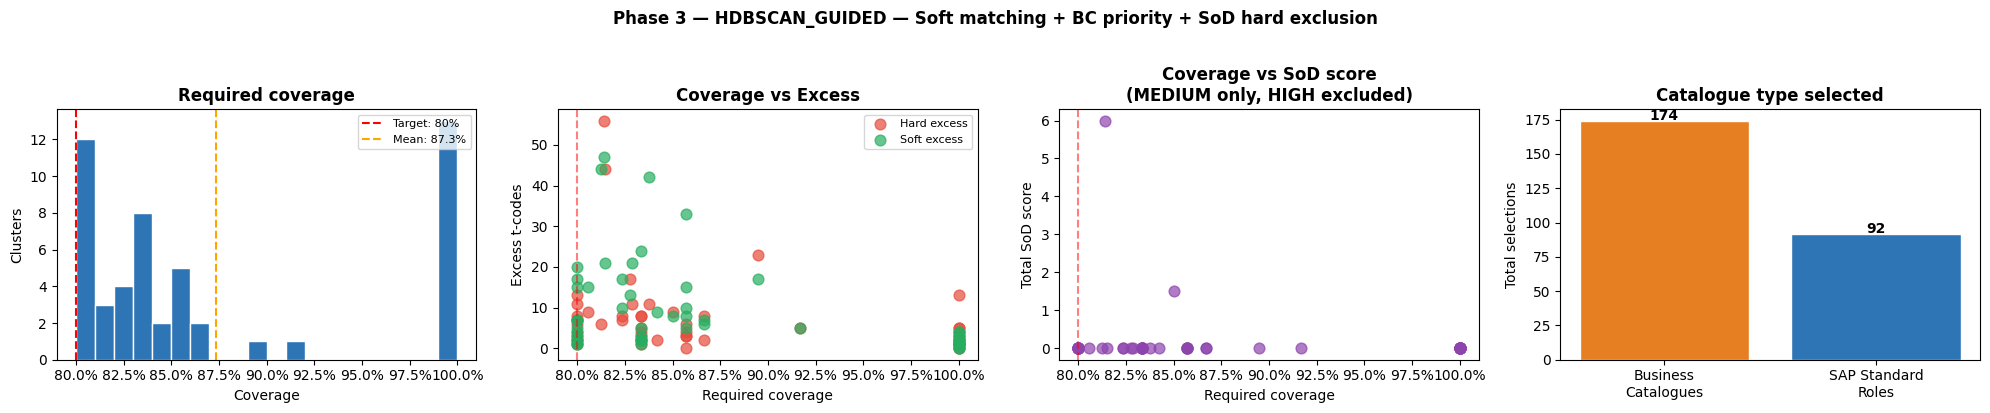

In [10]:
# Greedy Set Cover - Soft + BC priority + SoD hard exclusion

def get_soft_matches(tc_required, tc_role, model, threshold):
    soft_covered = set()
    soft_excess  = set()
    role_not_exact = tc_role - tc_required
    for role_tc in role_not_exact:
        if role_tc not in model.wv:
            continue
        for req_tc in tc_required:
            if req_tc not in model.wv:
                continue
            v1  = model.wv[role_tc]
            v2  = model.wv[req_tc]
            sim = float(np.dot(v1/np.linalg.norm(v1), v2/np.linalg.norm(v2)))
            if sim >= threshold:
                soft_covered.add(req_tc)
                soft_excess.add(role_tc)
                break
    return soft_covered, soft_excess


def has_high_sod_conflict(cand_tcodes, selected_tcodes,
                           sod_risk_dict, hard_threshold):
    """
    Returns True if candidate introduces any HIGH or CRITICAL
    SoD conflict with already selected t-codes.
    Hard exclusion - never select this candidate.
    """
    for tc in cand_tcodes:
        for sel_tc in selected_tcodes:
            key = (min(tc, sel_tc), max(tc, sel_tc))
            if sod_risk_dict.get(key, 0) >= hard_threshold:
                return True
    return False


def count_sod_conflicts(cand_tcodes, selected_tcodes, sod_risk_dict,
                        hard_threshold):
    """
    Compute weighted SoD score for MEDIUM and LOW conflicts only.
    HIGH and CRITICAL are handled by hard exclusion.
    """
    score = 0.0
    for tc in cand_tcodes:
        for sel_tc in selected_tcodes:
            key  = (min(tc, sel_tc), max(tc, sel_tc))
            risk = sod_risk_dict.get(key, 0)
            if 0 < risk < hard_threshold:  # only MEDIUM and LOW
                score += risk
    return score


def greedy_soft(cluster_id, cluster_prof, candidates, model,
                coverage_target     = 0.80,
                excess_penalty      = 0.30,
                soft_alpha          = 0.5,
                soft_threshold      = 0.70,
                soft_excess_penalty = 0.10,
                opt_weight          = 0.5,
                bc_priority_bonus   = 0.3,
                sod_penalty         = 0.5,
                sod_hard_threshold  = 2,
                sod_risk_dict       = None):

    required    = cluster_prof['required']
    optional    = cluster_prof['optional']
    cluster_all = required | optional

    if len(required) == 0:
        return []

    uncovered_req   = required.copy()
    uncovered_opt   = optional.copy()
    selected        = []
    used            = set()
    selected_tcodes = set()

    while True:
        coverage = 1 - len(uncovered_req) / len(required)
        if coverage >= coverage_target:
            break

        best_score = -np.inf
        best_cand  = None

        for cand, cand_tcodes in candidates.items():
            if cand in used:
                continue

            # Hard SoD exclusion (HIGH + CRITICAL)
            if sod_risk_dict and selected_tcodes:
                if has_high_sod_conflict(
                    cand_tcodes, selected_tcodes,
                    sod_risk_dict, sod_hard_threshold
                ):
                    continue  # skip this candidate entirely

            exact_req  = cand_tcodes & uncovered_req
            exact_opt  = cand_tcodes & uncovered_opt
            soft_req, soft_exc = get_soft_matches(
                uncovered_req, cand_tcodes, model, soft_threshold
            )
            soft_req    = soft_req - (cand_tcodes & required)
            hard_excess = (cand_tcodes - cluster_all) - soft_exc

            if len(exact_req) == 0 and len(soft_req) == 0 and \
               (opt_weight == 0 or len(exact_opt) == 0):
                continue

            # Soft SoD penalty (MEDIUM + LOW)
            sod_score = 0.0
            if sod_risk_dict and selected_tcodes:
                sod_score = count_sod_conflicts(
                    cand_tcodes, selected_tcodes,
                    sod_risk_dict, sod_hard_threshold
                )

            cand_type = combined_dict.get(cand, {}).get('type', 'UNKNOWN')

            score = (len(exact_req)
                     + soft_alpha          * len(soft_req)
                     + opt_weight          * len(exact_opt)
                     - excess_penalty      * len(hard_excess)
                     - soft_excess_penalty * len(soft_exc)
                     - sod_penalty         * sod_score)

            if cand_type == 'BC':
                score += bc_priority_bonus

            if score > best_score:
                best_score = score
                best_cand  = cand

        if best_cand is None:
            break

        # Add best candidate
        cand_tcodes = candidates[best_cand]
        exact_req   = cand_tcodes & uncovered_req
        exact_opt   = cand_tcodes & uncovered_opt
        soft_req, soft_exc = get_soft_matches(
            uncovered_req, cand_tcodes, model, soft_threshold
        )
        soft_req    = soft_req - (cand_tcodes & required)
        hard_excess = (cand_tcodes - cluster_all) - soft_exc
        cand_type   = combined_dict.get(best_cand, {}).get('type', 'UNKNOWN')

        sod_score          = 0.0
        sod_conflicts_detail = []
        if sod_risk_dict and selected_tcodes:
            for tc in cand_tcodes:
                for sel_tc in selected_tcodes:
                    key  = (min(tc, sel_tc), max(tc, sel_tc))
                    risk = sod_risk_dict.get(key, 0)
                    if 0 < risk < sod_hard_threshold:
                        sod_score += risk
                        sod_conflicts_detail.append(f'{tc}↔{sel_tc}')

        uncovered_req   -= exact_req
        uncovered_req   -= soft_req
        uncovered_opt   -= exact_opt
        selected_tcodes |= cand_tcodes
        used.add(best_cand)

        cov_after     = 1 - len(uncovered_req) / len(required)
        opt_cov_after = (1 - len(uncovered_opt) / len(optional)
                         if len(optional) > 0 else 1.0)

        selected.append({
            'CLUSTER_ID':         cluster_id,
            'CANDIDATE':          best_cand,
            'CANDIDATE_TYPE':     cand_type,
            'BC_DESC':            bc_desc_dict.get(best_cand, ''),
            'CANDIDATE_SIZE':     len(cand_tcodes),
            'EXACT_REQ_COVERED':  len(exact_req),
            'SOFT_REQ_COVERED':   len(soft_req),
            'EXACT_OPT_COVERED':  len(exact_opt),
            'HARD_EXCESS':        len(hard_excess),
            'SOFT_EXCESS':        len(soft_exc),
            'SOD_SCORE':          round(sod_score, 2),
            'SOD_CONFLICTS':      ' | '.join(sod_conflicts_detail[:10]),
            'SCORE':              round(best_score, 4),
            'COVERAGE_AFTER':     round(cov_after, 4),
            'OPT_COVERAGE_AFTER': round(opt_cov_after, 4),
            'HARD_EXCESS_TCODES': sorted(hard_excess),
            'SOFT_EXCESS_TCODES': sorted(soft_exc),
            'MISSING_REQ_TCODES': sorted(uncovered_req),
        })

    return selected


# Run greedy
print('═'*60)
print('GREEDY SET COVER — Soft + BC priority + SoD hard exclusion')
print(f'  Coverage target:      {COVERAGE_TARGET:.0%}')
print(f'  Excess penalty:       {EXCESS_PENALTY}')
print(f'  Soft alpha:           {SOFT_ALPHA}')
print(f'  Soft threshold:       {SOFT_THRESHOLD}')
print(f'  Soft excess penalty:  {SOFT_EXCESS_PENALTY}')
print(f'  Opt weight:           {OPT_WEIGHT}')
print(f'  BC priority bonus:    {BC_PRIORITY_BONUS}')
print(f'  SoD hard threshold:   HIGH+CRITICAL excluded')
print(f'  SoD penalty (medium): {SOD_PENALTY}')
print('═'*60)

all_matches = []
summary     = []

for cid, prof in cluster_profiles.items():
    if len(prof['required']) == 0:
        summary.append({
            'CLUSTER_ID':        cid,
            'N_JTS':             prof['n_jts'],
            'N_REQUIRED':        0,
            'N_OPTIONAL':        len(prof['optional']),
            'CANDS_SELECTED':    0,
            'N_BC':              0,
            'N_SAP_ROLE':        0,
            'REQ_COVERAGE':      0.0,
            'OPT_COVERAGE':      0.0,
            'TOTAL_HARD_EXCESS': 0,
            'TOTAL_SOFT_EXCESS': 0,
            'TOTAL_SOD_SCORE':   0.0,
            'N_MISSING':         0,
            'STATUS':            'NO_REQUIRED_TCODES',
            'SELECTED':          '',
        })
        continue

    candidates = cluster_candidates.get(cid, candidates_dict)
    matches    = greedy_soft(
        cluster_id          = cid,
        cluster_prof        = prof,
        candidates          = candidates,
        model               = w2v,
        coverage_target     = COVERAGE_TARGET,
        excess_penalty      = EXCESS_PENALTY,
        soft_alpha          = SOFT_ALPHA,
        soft_threshold      = SOFT_THRESHOLD,
        soft_excess_penalty = SOFT_EXCESS_PENALTY,
        opt_weight          = OPT_WEIGHT,
        bc_priority_bonus   = BC_PRIORITY_BONUS,
        sod_penalty         = SOD_PENALTY,
        sod_hard_threshold  = SOD_HARD_THRESHOLD,
        sod_risk_dict       = sod_risk_dict
    )

    all_matches.extend(matches)

    final       = matches[-1] if matches else {}
    req_cov     = final.get('COVERAGE_AFTER', 0.0)
    opt_cov     = final.get('OPT_COVERAGE_AFTER', 0.0)
    missing     = len(final.get('MISSING_REQ_TCODES', prof['required']))
    hard_excess = sum(m['HARD_EXCESS'] for m in matches)
    soft_excess = sum(m['SOFT_EXCESS'] for m in matches)
    sod_score   = sum(m['SOD_SCORE'] for m in matches)
    n_bc        = sum(1 for m in matches if m['CANDIDATE_TYPE'] == 'BC')
    n_sap       = sum(1 for m in matches if m['CANDIDATE_TYPE'] == 'SAP_ROLE')

    summary.append({
        'CLUSTER_ID':        cid,
        'N_JTS':             prof['n_jts'],
        'N_REQUIRED':        len(prof['required']),
        'N_OPTIONAL':        len(prof['optional']),
        'CANDS_SELECTED':    len(matches),
        'N_BC':              n_bc,
        'N_SAP_ROLE':        n_sap,
        'REQ_COVERAGE':      round(req_cov, 4),
        'OPT_COVERAGE':      round(opt_cov, 4),
        'TOTAL_HARD_EXCESS': hard_excess,
        'TOTAL_SOFT_EXCESS': soft_excess,
        'TOTAL_SOD_SCORE':   round(sod_score, 2),
        'N_MISSING':         missing,
        'STATUS':            'OK'      if req_cov >= COVERAGE_TARGET
                             else 'PARTIAL' if matches
                             else 'NO_MATCH',
        'SELECTED':          ' | '.join([
                                 f'{m["CANDIDATE"]}({m["CANDIDATE_TYPE"]})'
                                 for m in matches
                             ]),
    })

    print(f'  Cluster {cid:>4}  '
          f'jts={prof["n_jts"]:>3}  '
          f'req={len(prof["required"]):>3}  '
          f'opt={len(prof["optional"]):>3}  '
          f'cands={len(matches):>2} (bc={n_bc} sap={n_sap})  '
          f'req_cov={req_cov:.0%}  '
          f'opt_cov={opt_cov:.0%}  '
          f'hard_exc={hard_excess:>3}  '
          f'soft_exc={soft_excess:>3}  '
          f'sod={sod_score:>5.1f}  '
          f'miss={missing:>3}  '
          f'{summary[-1]["STATUS"]}')

df_matches = pd.DataFrame(all_matches)
df_summary = pd.DataFrame(summary)

print(f'\n{"═"*60}')
print(f'SUMMARY')
print(f'{"═"*60}')
print(f'  OK (>= {COVERAGE_TARGET:.0%}):    {(df_summary["STATUS"]=="OK").sum()}')
print(f'  Partial:              {(df_summary["STATUS"]=="PARTIAL").sum()}')
print(f'  No required tc:       {(df_summary["STATUS"]=="NO_REQUIRED_TCODES").sum()}')
print(f'  No match:             {(df_summary["STATUS"]=="NO_MATCH").sum()}')
print(f'  Mean req coverage:    {df_summary["REQ_COVERAGE"].mean():.1%}')
print(f'  Mean opt coverage:    {df_summary["OPT_COVERAGE"].mean():.1%}')
print(f'  Mean cands/cluster:   {df_summary["CANDS_SELECTED"].mean():.1f}')
print(f'  Mean hard excess:     {df_summary["TOTAL_HARD_EXCESS"].mean():.1f}')
print(f'  Mean soft excess:     {df_summary["TOTAL_SOFT_EXCESS"].mean():.1f}')
print(f'  Mean SoD score:       {df_summary["TOTAL_SOD_SCORE"].mean():.1f}')
print(f'  BC selected:          {df_summary["N_BC"].sum()}')
print(f'  SAP role selected:    {df_summary["N_SAP_ROLE"].sum()}')

# Plots
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

axes[0].hist(df_summary['REQ_COVERAGE'], bins=20,
             color='#2E75B6', edgecolor='white')
axes[0].axvline(COVERAGE_TARGET, color='red', linestyle='--',
                label=f'Target: {COVERAGE_TARGET:.0%}')
axes[0].axvline(df_summary['REQ_COVERAGE'].mean(), color='orange',
                linestyle='--',
                label=f'Mean: {df_summary["REQ_COVERAGE"].mean():.1%}')
axes[0].set_title('Required coverage', fontweight='bold')
axes[0].set_xlabel('Coverage')
axes[0].set_ylabel('Clusters')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].legend(fontsize=8)

axes[1].scatter(df_summary['REQ_COVERAGE'],
                df_summary['TOTAL_HARD_EXCESS'],
                color='#E74C3C', alpha=0.7, s=60, label='Hard excess')
axes[1].scatter(df_summary['REQ_COVERAGE'],
                df_summary['TOTAL_SOFT_EXCESS'],
                color='#27AE60', alpha=0.7, s=60, label='Soft excess')
axes[1].axvline(COVERAGE_TARGET, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Coverage vs Excess', fontweight='bold')
axes[1].set_xlabel('Required coverage')
axes[1].set_ylabel('Excess t-codes')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].legend(fontsize=8)

axes[2].scatter(df_summary['REQ_COVERAGE'],
                df_summary['TOTAL_SOD_SCORE'],
                color='#8E44AD', alpha=0.7, s=60)
axes[2].axvline(COVERAGE_TARGET, color='red', linestyle='--', alpha=0.5)
axes[2].set_title('Coverage vs SoD score\n(MEDIUM only, HIGH excluded)',
                  fontweight='bold')
axes[2].set_xlabel('Required coverage')
axes[2].set_ylabel('Total SoD score')
axes[2].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))

bc_total  = df_summary['N_BC'].sum()
sap_total = df_summary['N_SAP_ROLE'].sum()
axes[3].bar(['Business\nCatalogues', 'SAP Standard\nRoles'],
            [bc_total, sap_total],
            color=['#E67E22', '#2E75B6'], edgecolor='white')
axes[3].set_title('Catalogue type selected', fontweight='bold')
axes[3].set_ylabel('Total selections')
for bar, val in zip(axes[3].patches, [bc_total, sap_total]):
    axes[3].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 str(val), ha='center', fontweight='bold')

plt.suptitle(
    f'Phase 3 — {CLUSTERING_METHOD} — Soft matching + BC priority + SoD hard exclusion',
    fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# Export

output_path = f'{OUTPUT_DIR}/phase3_{CLUSTERING_METHOD.lower()}_results.xlsx'

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:

    # Sheet 1 — Cluster summary
    df_summary.sort_values('CLUSTER_ID').to_excel(
        writer, sheet_name='Cluster Summary', index=False)

    # Sheet 2 — Candidate detail
    if not df_matches.empty:
        df_matches.sort_values(
            ['CLUSTER_ID', 'COVERAGE_AFTER']
        ).to_excel(writer, sheet_name='Candidate Detail', index=False)

    # Sheet 3 — Missing required t-codes
    missing_rows = []
    for cid, prof in cluster_profiles.items():
        row = df_summary[df_summary['CLUSTER_ID'] == cid]
        if row.empty:
            continue
        m = df_matches[df_matches['CLUSTER_ID'] == cid]
        missing_tc = sorted(m.iloc[-1]['MISSING_REQ_TCODES']) \
                     if not m.empty else sorted(prof['required'])
        for tc in missing_tc:
            missing_rows.append({
                'CLUSTER_ID':  cid,
                'N_JTS':       prof['n_jts'],
                'JOB_TITLES':  ' | '.join(prof['job_titles'][:5]),
                'TCODE':       tc,
                'NOTE':        'Not covered by any BC or SAP role'
            })
    if missing_rows:
        pd.DataFrame(missing_rows).to_excel(
            writer, sheet_name='Missing T-codes', index=False)

    # Sheet 4 — Cluster profiles
    profile_rows = []
    for cid, prof in cluster_profiles.items():
        profile_rows.append({
            'CLUSTER_ID':      cid,
            'N_JTS':           prof['n_jts'],
            'JOB_TITLES':      ' | '.join(prof['job_titles']),
            'REQUIRED_TCODES': ', '.join(sorted(prof['required'])),
            'OPTIONAL_TCODES': ', '.join(sorted(prof['optional'])),
            'N_REQUIRED':      len(prof['required']),
            'N_OPTIONAL':      len(prof['optional']),
        })
    pd.DataFrame(profile_rows).sort_values('CLUSTER_ID').to_excel(
        writer, sheet_name='Cluster Profiles', index=False)

    # Sheet 5 — Parameters
    pd.DataFrame({
        'PARAMETER': [
            'CLUSTERING_METHOD', 'PREVALENCE_REQUIRED', 'PREVALENCE_OPTIONAL',
            'MAX_ROLE_SIZE', 'W2V_VECTOR_SIZE', 'W2V_EPOCHS',
            'TOP_CANDIDATES', 'COVERAGE_TARGET', 'EXCESS_PENALTY',
            'SOFT_ALPHA', 'SOFT_THRESHOLD', 'SOFT_EXCESS_PENALTY', 'OPT_WEIGHT',
            'BCs in catalogue', 'SAP roles in catalogue',
            'Total candidates', 'Clusters processed'
        ],
        'VALUE': [
            CLUSTERING_METHOD, PREVALENCE_REQUIRED, PREVALENCE_OPTIONAL,
            MAX_ROLE_SIZE, W2V_VECTOR_SIZE, W2V_EPOCHS,
            TOP_CANDIDATES, COVERAGE_TARGET, EXCESS_PENALTY,
            SOFT_ALPHA, SOFT_THRESHOLD, SOFT_EXCESS_PENALTY, OPT_WEIGHT,
            len(bc_dict), len(roles_dict),
            len(combined_dict), len(cluster_profiles)
        ]
    }).to_excel(writer, sheet_name='Parameters', index=False)

print(f'  Exported: {output_path}')
print(f'  Sheet 1 — Cluster Summary:    {len(df_summary)} clusters')
print(f'  Sheet 2 — Candidate Detail:   {len(df_matches)} assignments')
print(f'  Sheet 3 — Missing T-codes:    {len(missing_rows)} rows')
print(f'  Sheet 4 — Cluster Profiles:   {len(profile_rows)} clusters')
print(f'  Sheet 5 — Parameters')

# Validation metrics
print('\n' + '═'*60)
print('VALIDATION METRICS')
print('═'*60)

ok_mask     = df_summary['STATUS'] == 'OK'
partial_mask = df_summary['STATUS'] == 'PARTIAL'
no_req_mask = df_summary['STATUS'] == 'NO_REQUIRED_TCODES'

print(f'  Clusters processed:          {len(df_summary)}')
print(f'  Reached {COVERAGE_TARGET:.0%} target (OK):      {ok_mask.sum()} ({ok_mask.mean():.1%})')
print(f'  Partial (<{COVERAGE_TARGET:.0%}):             {partial_mask.sum()} ({partial_mask.mean():.1%})')
print(f'  No required t-codes:         {no_req_mask.sum()}')
print()
print(f'  Coverage (required):')
active = df_summary[~no_req_mask]
print(f'    Mean:   {active["REQ_COVERAGE"].mean():.1%}')
print(f'    Median: {active["REQ_COVERAGE"].median():.1%}')
print(f'    Min:    {active["REQ_COVERAGE"].min():.1%}')
print(f'    Max:    {active["REQ_COVERAGE"].max():.1%}')
print()
print(f'  Coverage (optional):')
print(f'    Mean:   {active["OPT_COVERAGE"].mean():.1%}')
print()
print(f'  Role assignments per cluster:')
print(f'    Mean:   {active["CANDS_SELECTED"].mean():.1f}')
print(f'    Max:    {active["CANDS_SELECTED"].max()}')
print()
print(f'  Hard excess t-codes per cluster:')
print(f'    Mean:   {active["TOTAL_HARD_EXCESS"].mean():.1f}')
print(f'    Median: {active["TOTAL_HARD_EXCESS"].median():.0f}')
print()
print(f'  SoD score (MEDIUM conflicts, soft):')
print(f'    Mean:   {active["TOTAL_SOD_SCORE"].mean():.1f}')
print(f'    Clusters with SoD > 0: {(active["TOTAL_SOD_SCORE"] > 0).sum()}')

# Clusters that didn't reach target
if partial_mask.sum() > 0:
    print(f'\n  Partial clusters (coverage < {COVERAGE_TARGET:.0%}):')
    partial_df = df_summary[partial_mask][['CLUSTER_ID','N_JTS','N_REQUIRED','REQ_COVERAGE','N_MISSING']].sort_values('REQ_COVERAGE')
    print(partial_df.to_string(index=False))

  Exported: output phase3/hdbscan_guided_results/phase3_hdbscan_guided_results.xlsx
  Sheet 1 — Cluster Summary:    51 clusters
  Sheet 2 — Candidate Detail:   266 assignments
  Sheet 3 — Missing T-codes:    118 rows
  Sheet 4 — Cluster Profiles:   51 clusters
  Sheet 5 — Parameters

════════════════════════════════════════════════════════════
VALIDATION METRICS
════════════════════════════════════════════════════════════
  Clusters processed:          51
  Reached 80% target (OK):      51 (100.0%)
  Partial (<80%):             0 (0.0%)
  No required t-codes:         0

  Coverage (required):
    Mean:   87.3%
    Median: 83.3%
    Min:    80.0%
    Max:    100.0%

  Coverage (optional):
    Mean:   26.5%

  Role assignments per cluster:
    Mean:   5.2
    Max:    20

  Hard excess t-codes per cluster:
    Mean:   7.3
    Median: 5

  SoD score (MEDIUM conflicts, soft):
    Mean:   0.1
    Clusters with SoD > 0: 2
